<a href="https://colab.research.google.com/github/ruchithagoud-hash/viswam-ai-chat-assistant-/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/Restaurant_Reviews.tsv",
    delimiter='\t',
    encoding='latin-1'
)

df.head()

,ï»¿Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [ ]:
df.columns = ['review', 'sentiment']

In [ ]:
df.head()

,review,sentiment
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
X = df['clean_review']
y = df['sentiment']

KeyError: 'clean_review'

In [ ]:
nltk.download('stopwords')

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

df.head()

In [ ]:
X = df['clean_review']
y = df['sentiment']

In [ ]:
print(X.head())
print(y.head())

In [ ]:
X = df['clean_review']
y = df['sentiment']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)S

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Restaurant_Reviews.tsv", delimiter='\t', encoding='latin-1')
df.columns = ['review', 'sentiment']
df.head()

,review,sentiment
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,sentiment,clean_review
0,Wow... Loved this place.,1,wow loved place
1,Crust is not good.,0,crust good
2,Not tasty and the texture was just nasty.,0,tasty texture nasty
3,Stopped by during the late May bank holiday of...,1,stopped late may bank holiday rick steve recom...
4,The selection on the menu was great and so wer...,1,selection menu great prices


In [ ]:
X = df['clean_review']
y = df['sentiment']

In [ ]:
print(X.head())
print(y.head())

0                                      wow loved place
1                                           crust good
2                                  tasty texture nasty
3    stopped late may bank holiday rick steve recom...
4                          selection menu great prices
Name: clean_review, dtype: object
0    1
1    0
2    0
3    1
4    1
Name: sentiment, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

In [ ]:
print(type(X))

<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(800, 1890)
(200, 1890)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.76


In [ ]:
new_review = ["The food was amazing and service was great"]

new_review_clean = [clean_text(new_review[0])]
new_review_vector = vectorizer.transform(new_review_clean)

prediction = model.predict(new_review_vector)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😡")

Positive Review 😊


In [ ]:
new_review = ["Worst food ever, very bad service"]

new_review_clean = [clean_text(new_review[0])]
new_review_vector = vectorizer.transform(new_review_clean)

prediction = model.predict(new_review_vector)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😡")

Negative Review 😡


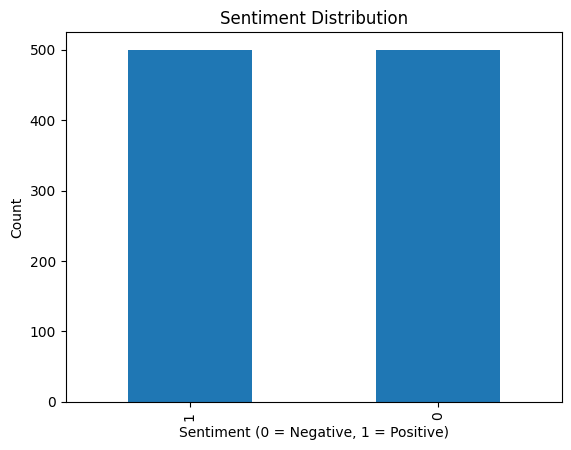

In [ ]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

In [ ]:
!pip install wordcloud

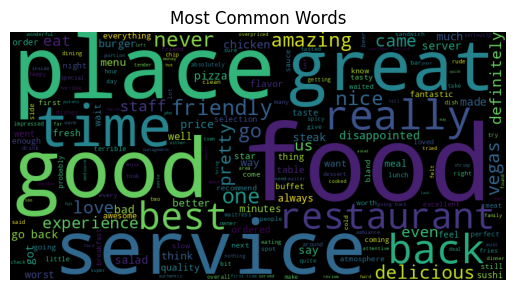

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_review'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Common Words")
plt.show()